## Building input pipelines in Pytorch

If the dataset is small, we can load it as tensor into memory, we can directly use this tensor for training but if the training dataset is large, we have to load them in chunks. In addition, we may have to construct a data-processing pipeline to apply any preprocessing steps.

In [5]:
import os
import numpy as np
import pathlib
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from PIL import Image

If data already exist in the form of tensor, we can create a dataset loader.

In [3]:
t = torch.arange(6, dtype = torch.float32)
data_loader = DataLoader(t)

In [4]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


We can also create batched from this dataset.

In [ ]:
data_loader = DataLoader(t, batch_size=3, drop_last=False) #drop_last in case data size is not divisible by batch_size
for i, batch in enumerate(data_loader, start = 1):
    print(f'Batch {i}:', batch)

Batch 1: tensor([0., 1., 2.])
Batch 2: tensor([3., 4., 5.])


In [7]:
# Combining two datasets into a joint dataset
torch.manual_seed(1)
t_x = torch.rand([4,3], dtype = torch.float32)
t_y = torch.arange(4)

In [9]:
class JointDataset(Dataset):
    def __init__(self, x, y): #initial logic, reading data, filtering, etc.
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx): # return the corresponding sample to the given index.
        return self.x[idx], self.y[idx]

In [10]:
joint_dataset = JointDataset(t_x, t_y)

In [11]:
joint_dataset

In [12]:
for example in joint_dataset:
    print(' x: ', example[0], ' y: ', example[1])

 x:  tensor([0.7576, 0.2793, 0.4031])  y:  tensor(0)
 x:  tensor([0.7347, 0.0293, 0.7999])  y:  tensor(1)
 x:  tensor([0.3971, 0.7544, 0.5695])  y:  tensor(2)
 x:  tensor([0.4388, 0.6387, 0.5247])  y:  tensor(3)


### Shuffle, batch, repeat

In [13]:
## Shuffle the dataset
torch.manual_seed(1)
data_loader = DataLoader(dataset= joint_dataset, batch_size= 2, shuffle = True)

In [16]:
for i, batch in enumerate(data_loader, 1):
    print(f'Batch {i}:', 'x:' ,batch[0], 
          '\n       y:', batch[1])

Batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
       y: tensor([3, 2])
Batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
       y: tensor([0, 1])


The rows are shuffled without losing the one-to-one correspondence between the enteries in x and y.

When training a model for multiple epochs, we need to shuffle and iterate over the dataset by the desired number of epochs.

In [17]:
for epoch in range(2):
    print(f'epoch {epoch + 1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'Batch {i}:', 'x:' ,batch[0], 
          '\n       y:', batch[1])

epoch 1
Batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.4388, 0.6387, 0.5247]]) 
       y: tensor([0, 3])
Batch 2: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7347, 0.0293, 0.7999]]) 
       y: tensor([2, 1])
epoch 2
Batch 1: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
       y: tensor([1, 3])
Batch 2: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
       y: tensor([2, 0])


## Creating a dataset from the files on your local storage

In [3]:
imgdir_path = pathlib.Path('data/cat_dog_images')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')]) # glob is to search for file with a specific pattern.
print(file_list)

['data/cat_dog_images/cat-01.jpg', 'data/cat_dog_images/cat-02.jpg', 'data/cat_dog_images/cat-03.jpg', 'data/cat_dog_images/dog-01.jpg', 'data/cat_dog_images/dog-02.jpg', 'data/cat_dog_images/dog-03.jpg']


Image shape: (900, 1200, 3)
Image shape: (900, 1200, 3)
Image shape: (900, 742, 3)
Image shape: (800, 1200, 3)
Image shape: (800, 1200, 3)
Image shape: (900, 1200, 3)


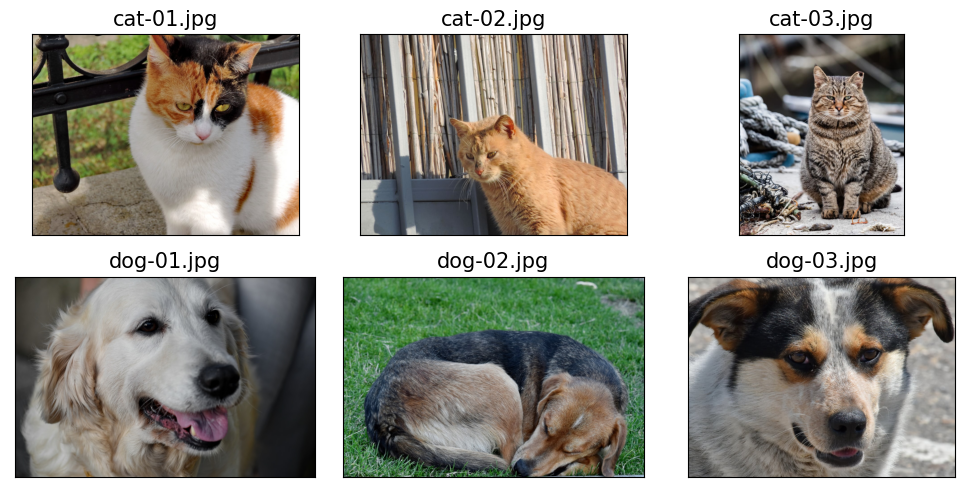

In [8]:
fig = plt.figure(figsize= (10,5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape:', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size = 15)
plt.tight_layout()
plt.show()

Aspect ratio is different for each image. Some are 900 X 1200, some are 900 X 800, etc. We will preprocess the image to a consistent size.

In [9]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]
